# Preprocesamiento

## Estudio inicial de datos

Utilizando un datasets muy conocido 'IRIS', vamos a estudiar como son sus datos y como están distruidas en función de la clase.

In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

# Importante poner para que se muestren los gráficos
%matplotlib inline

In [2]:
# Importación de los módulos necesarios de la biblioteca scikit learn
from sklearn import datasets

# Importamos el conjunto de datos como un dataframe para ver la estructura 
datos,etiquetas = datasets.load_iris(return_X_y=True, as_frame=True)
iris = pd.concat([datos,etiquetas], axis= 1)
iris.rename(columns={'target':'especie'}, inplace=True)

Como las clases vienen numéricas, para una mejor visualización, vamos a mapear los números con etiquetas de clase.

In [3]:
mapeo = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
iris['especie'] = iris['especie'].map(mapeo)
#Contamos los valores de cada clase para ver si es un dataset balanceado o no.
iris['especie'].value_counts()

especie
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Antes que nada vamos a examinar el dataset, empezando por examinar los tipos

In [4]:
iris.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
especie               object
dtype: object

Ahora analizamos algunos estadísticos asociados a los datos. 

In [5]:
iris.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Ahora analizamos los datos por boxplot y también por gráficos de dispersión.

<Axes: >

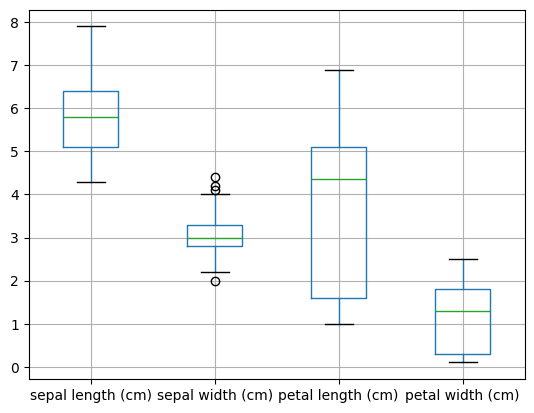

In [6]:
iris.boxplot()

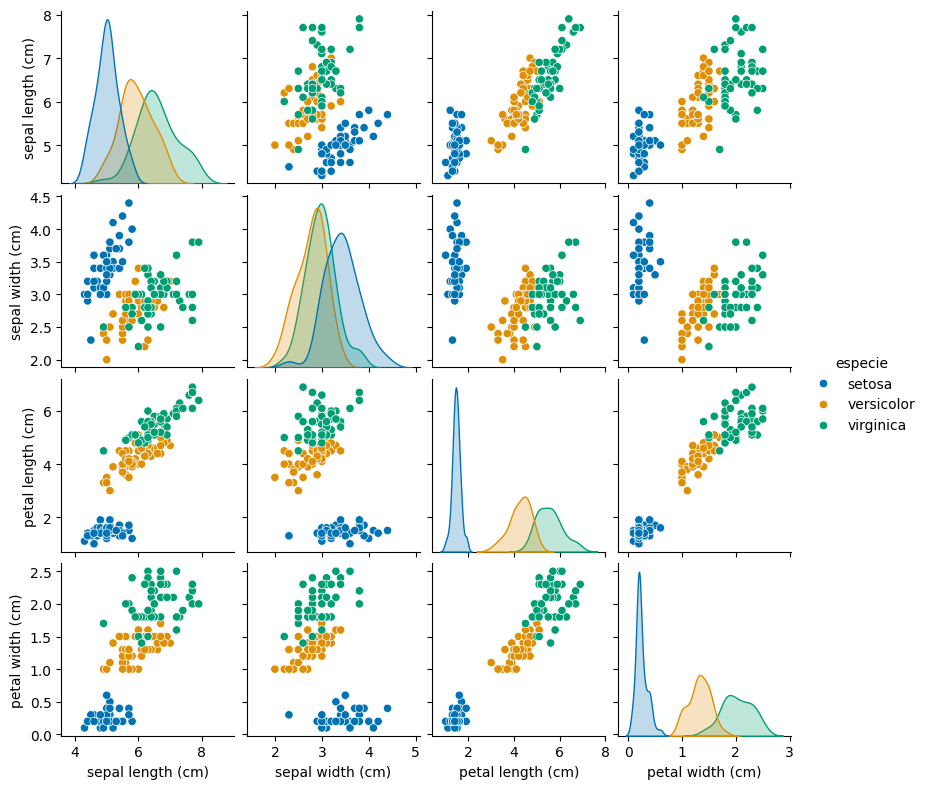

In [7]:
sns.pairplot(iris, hue="especie", height = 2, palette = 'colorblind');

Ahora si queremos ya podemos quitar columnas que no nos interesen, o quitar instancias y clasificar el problema sólo en dos clases. Por ejemplo si quisiera sólo analiar las dos clases problemáticas que son iris virginicia e iris versicolor y quitar dos columnas.

In [8]:
iris_petalo = iris.drop(columns = ['sepal length (cm)', 'sepal width (cm)'])
iris_petalo = iris_petalo[iris_petalo['especie'].isin(['versicolor','virginica'])]
iris_petalo

,petal length (cm),petal width (cm),especie
50,4.7,1.4,versicolor
51,4.5,1.5,versicolor
52,4.9,1.5,versicolor
53,4.0,1.3,versicolor
54,4.6,1.5,versicolor
...,...,...,...
145,5.2,2.3,virginica
146,5.0,1.9,virginica
147,5.2,2.0,virginica
148,5.4,2.3,virginica


Visualizamos las distribuciones por clase

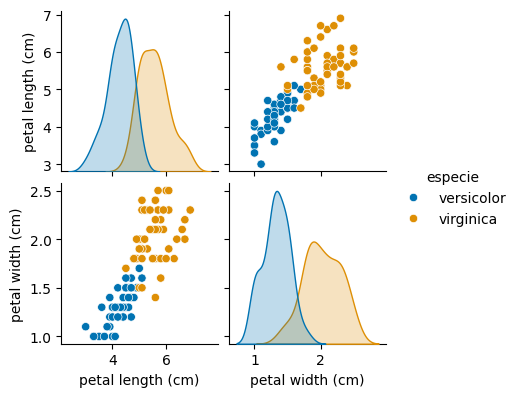

In [9]:
sns.pairplot(iris_petalo, hue="especie", height = 2, palette = 'colorblind');


## Estrategia one-hot-encoding

Las variables dummy son variables ficticias que se crean para codificar variables categóricas. Estas variables consisten en crear por cada categórica una nueva variable binaria (también llamada dummy).  Así, estas nuevas variables contendrán 1 en aquellas observaciones que pertenezcan a esa categoría y 0 en el resto. Para crear estas variables dummy se utiliza la estrategia one-hot-encoding. En phyton tenemos mucha formas de realizar esta estrategia. Vamos a ver dos formas de realizar la estrategia una utilizando la librería `Scikit-Learn` con la funcionalidad en el módulo `sklearn.preprocessing`.`OneHotEncoder()` y la otra utilizando Pandas con la función `pandas.get_dummies()`

In [10]:
#librerias
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sklearn.metrics as metrics
from sklearn.preprocessing import StandardScaler
from scipy.cluster import hierarchy
from sklearn.cluster import AgglomerativeClustering

In [11]:
#Siempre establecer la semilla
semilla=123
np.random.seed(semilla)


# Descarga de datos de la base de datos titanic
# ==============================================================================
url = ( 'titanic.csv')
datos = pd.read_csv(url, sep=';')
datos.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,"22,0",1,0,"7,25",S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,"38,0",1,0,"71,2833",C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,"26,0",0,0,"7,925",S,Third,woman,False,NaN,Southampton,yes,True


In [12]:
# Ahora identificamos para cada atributo su tipo
datos.dtypes

survived        int64
pclass          int64
sex            object
age            object
sibsp           int64
parch           int64
fare           object
embarked       object
class          object
who            object
adult_male       bool
deck           object
embark_town    object
alive          object
alone            bool
dtype: object

In [13]:
categoricas = datos.select_dtypes(include = ["object", "category"]).columns
# Mostramos las columnas extraídas
categoricas

Index(['sex', 'age', 'fare', 'embarked', 'class', 'who', 'deck', 'embark_town',
       'alive'],
      dtype='object')

Utilizamos la función `pd.get_dummies()`  en el subconjunto del dataframe datos formado por estas columnas extraídas.
En esta función utilizamos dos argumentos que son `drop_first` y `dummy_na`.

- `drop_first = True`: Este argumento permite eliminar la primera de las columnas generadas para cada característica con el objetivo de evitar la colinealidad (que una de las columnas sea combinación lineal de las demás)
- `dummy_na = True`: Este argumento permite que se genere una columna adicional para los valores nulos que se encuentren en cada característica

In [14]:
categoricas_Datos = pd.get_dummies(datos[categoricas], drop_first = True, dummy_na = True)
# Mostramos la transformación de las variables categóricas en variables dummies
categoricas_Datos.head()

,sex_male,sex_nan,"age_0,67","age_0,75","age_0,83","age_0,92","age_1,0","age_10,0","age_11,0","age_12,0",...,deck_D,deck_E,deck_F,deck_G,deck_nan,embark_town_Queenstown,embark_town_Southampton,embark_town_nan,alive_yes,alive_nan
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,True,False,True,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
4,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,True,False,False,False


Ahora eliminamos los atributos originales 

In [15]:
datos.drop(categoricas, axis = 1, inplace = True)
# Tras eliminar los atributos originales, concatenamos los nuevos atributos creados para las variables categóricas.
datos = pd.concat([datos, categoricas_Datos], axis = 1)
# Mostramos como quedan los datos de nuevo.
datos.head()

,survived,pclass,sibsp,parch,adult_male,alone,sex_male,sex_nan,"age_0,67","age_0,75",...,deck_D,deck_E,deck_F,deck_G,deck_nan,embark_town_Queenstown,embark_town_Southampton,embark_town_nan,alive_yes,alive_nan
0,0,3,1,0,True,False,True,False,False,False,...,False,False,False,False,True,False,True,False,False,False
1,1,1,1,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,1,3,0,0,False,True,False,False,False,False,...,False,False,False,False,True,False,True,False,True,False
3,1,1,1,0,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
4,0,3,0,0,True,True,True,False,False,False,...,False,False,False,False,True,False,True,False,False,False


## Normalización

Aplicamos la normalización o estandarización de datos para que todos los atributos tengan las mismas dimensiones. Para realizar esta tarea emplearemos la clase `StandardScaler()` de Scikit-learn.

In [16]:
# Importamos la clase StandardScaler para realizar el escalado
from sklearn.preprocessing import StandardScaler
# Importamos la clase LinearSVC
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split

# Instanciamos el escalador
scaler = StandardScaler()

Hay que calcular la estandarización  y aplicar la transformación generada al conjunto de entrenamiento y de test.

In [17]:
X=datos.drop["survived"]
y=datos["survived"]
X_train, X_test, y_train, y_test = train_test_split(X,y , test_size=0.2,random_state=np.random.seed(0))

X_ent_escaladas = pd.DataFrame(scaler.fit_transform(X_train),columns=X_train.columns)

X_test_escaladas = pd.DataFrame(scaler.transform(X_test),columns=X_test.columns)

print(X_ent_escaladas)

# ¿¿Funcionaaa??? ¿¿Puedo visualizar algo??
X_ent_escaladas.boxplot()

TypeError: 'method' object is not subscriptable

¿ Y ahora cuál sería el procedimiento?, ¿con que características entreno el modelo?

## Selección de Instancias

Primero vamos a definir algunas funciones que nos van a ayudar a mostrar visualmente como funcionan alguno de los algoritmos de selección de instancias.

Veamos como funciona el método de condensación de Instancias CNN.

In [ ]:
from collections import Counter  
from sklearn.datasets import fetch_openml  
from sklearn.preprocessing import scale  
from imblearn.under_sampling import CondensedNearestNeighbour  
X, y = fetch_openml('diabetes', version=1, return_X_y=True)  
X = scale(X)  
print('Original dataset  %s' % Counter(y))  
cnn = CondensedNearestNeighbour(random_state=42)  
X_res, y_res = cnn.fit_resample(X, y)  
print('Condensado dataset  %s' % Counter(y_res))  

Original dataset  Counter({'tested_negative': 500, 'tested_positive': 268})
Condensado dataset  Counter({'tested_positive': 268, 'tested_negative': 181})


Ahora probemos con el método de condensación editado ECNN.

In [ ]:
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.under_sampling import EditedNearestNeighbours


X, y = make_classification(n_classes=2, class_sep=2,
weights=[0.1, 0.9], n_informative=3, n_redundant=1, flip_y=0,
n_features=20, n_clusters_per_class=1, n_samples=1000, random_state=10)
print('Original dataset shape %s' % Counter(y))
print("-----------------------------")


enn = EditedNearestNeighbours()
X_res, y_res = enn.fit_resample(X, y)
print('Resampled dataset shape %s' % Counter(y_res))
cnn = CondensedNearestNeighbour(random_state=42)  
X_res, y_res = cnn.fit_resample(X, y)  
print("-----------------------------")


print('Condensado dataset  %s' % Counter(y_res))  

Original dataset shape Counter({1: 900, 0: 100})
-----------------------------
Resampled dataset shape Counter({1: 887, 0: 100})
-----------------------------
Condensado dataset  Counter({0: 100, 1: 44})


¿Cuál es mejor y porque? ¿Es necesario realizar algún experimento adicional para determinar el mejor método?

## Selección de características

In [ ]:
# Data Processing
import pandas as pd
import numpy as np
import random

# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from scipy.stats import randint
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, RepeatedStratifiedKFold
from sklearn.feature_selection import RFE, RFECV, SelectKBest, f_classif

import sklearn.datasets as dt

#Random Seed para reproducibilidad
random_seed = 1234

np.random.seed(random_seed)
random.seed(random_seed)

### Eliminación recursiva de variables (método wrapper)

En esta sección vamos a implementar el proceso de eliminación recursiva de variables, un método de tipo wrapper en el que, en este caso, vamos a utilizar un Random Forest cómo técnica de aprendizaje para evaluar los diferentes subconjunto de variables. 

Primero vamos a cargar el data set de ejemplo

Cargamos la base de datos

In [ ]:
cancer_X, cancer_y = dt.load_breast_cancer(return_X_y=True, as_frame=True)
cancer_X.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
cancer_y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 569 entries, 0 to 568
Series name: target
Non-Null Count  Dtype
--------------  -----
569 non-null    int32
dtypes: int32(1)
memory usage: 2.4 KB


Dividimos la base de datos y creamos el clasificador con todas las características

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(cancer_X, cancer_y, test_size=0.2,random_state=np.random.seed(1234))
rf = RandomForestClassifier(random_state=np.random.seed(1234))
rf.fit(X_train, y_train)

RandomForestClassifier()

Buscamos saber la precisión con todas las características

In [ ]:
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9298245614035088


Analizamos el ranking que randon forest me da de características

In [ ]:
rf.feature_importances_

array([0.04454426, 0.0142371 , 0.06090073, 0.02660899, 0.01071894,
       0.00870009, 0.0734777 , 0.08231494, 0.0022437 , 0.00295129,
       0.00384092, 0.00307503, 0.00981593, 0.02221053, 0.00338469,
       0.00237431, 0.00364364, 0.00663164, 0.00292415, 0.00411187,
       0.11474639, 0.0134657 , 0.16249481, 0.10741847, 0.01501359,
       0.02257026, 0.02346582, 0.13216122, 0.01158429, 0.00836901])

Aplicamos la reducción recursiva de características con RFE eso si tenemos que indicar el máximo de características con las que queremos quedarnos.

In [ ]:
n_features_to_select = 8
rfe = RFE(RandomForestClassifier(random_state=np.random.seed(1234)), n_features_to_select=n_features_to_select)
rfe.fit(X_train, y_train)

RFE(estimator=RandomForestClassifier(), n_features_to_select=8)

Vemos las variables seleccionadas

In [ ]:
from operator import itemgetter
features = X_train.columns.to_list()
for x, y in (sorted(zip(rfe.ranking_ , features), key=itemgetter(0))):
    print(x, y)

1 mean concavity
1 mean concave points
1 area error
1 worst radius
1 worst perimeter
1 worst area
1 worst concavity
1 worst concave points
2 worst smoothness
3 mean radius
4 mean area
5 mean perimeter
6 mean texture
7 worst compactness
8 worst texture
9 mean smoothness
10 mean compactness
11 perimeter error
12 worst fractal dimension
13 worst symmetry
14 radius error
15 compactness error
16 symmetry error
17 fractal dimension error
18 texture error
19 concavity error
20 smoothness error
21 concave points error
22 mean fractal dimension
23 mean symmetry


¿Qué faltaría para saber si el modelo es mejor sin todas las características?

Todo se podría meter en un pipeline, para agilizarlo

In [ ]:
from sklearn.pipeline import Pipeline
rfe = RFE(RandomForestClassifier(random_state=np.random.seed(1234)), n_features_to_select=n_features_to_select)
model = RandomForestClassifier(random_state=np.random.seed(1234))
pipeline = Pipeline(steps=[('s',rfe),('m',model)])

Se realiza una validación cruzada estratificada (asegurar balanceo de las clases test y train). Despues se muestra el % de accuracy.

In [ ]:
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
n_scores = cross_val_score(pipeline, X_train, y_train, scoring='accuracy', cv=cv, n_jobs=-1)
print('Accuracy: %.3f (%.3f)' % (np.mean(n_scores), np.std(n_scores)))

Accuracy: 0.955 (0.037)


También se puede hacer la eliminación recursiva utilizando la validación cruzada con sklearn.feature_selection.RFECV() 

### Selección de características con filtros

Los métodos de selección de variables basados en filtros se caracterizan por ser técnicas basadas en test estadísticos univariantes. En `scikit learn` se realizan a través de la función `sklearn.feature_selection.SelectKBest()`. Hay para elegir varios tipos en el ejemplo usaremos f_classif como medida.

In [ ]:
k=15
Kbest = SelectKBest(f_classif, k=k).fit(cancer_X,cancer_y)
X_new = Kbest.fit_transform(cancer_X,cancer_y)
X_new = pd.DataFrame(X_new, columns=Kbest.get_feature_names_out())

Ver la importancia de las variables de forma gráfica

In [ ]:
Kbest.scores_

array([6.46981021e+02, 1.18096059e+02, 6.97235272e+02, 5.73060747e+02,
       8.36511234e+01, 3.13233079e+02, 5.33793126e+02, 8.61676020e+02,
       6.95274435e+01, 9.34592949e-02, 2.68840327e+02, 3.90947023e-02,
       2.53897392e+02, 2.43651586e+02, 2.55796780e+00, 5.32473391e+01,
       3.90144816e+01, 1.13262760e+02, 2.41174067e-02, 3.46827476e+00,
       8.60781707e+02, 1.49596905e+02, 8.97944219e+02, 6.61600206e+02,
       1.22472880e+02, 3.04341063e+02, 4.36691939e+02, 9.64385393e+02,
       1.18860232e+02, 6.64439606e+01])

¿Qué faltaría? ¿Cuál sería el proceso completo a seguir?

# RETO I

Partiendo del dataset spamBase, aplica las técnicas de preprocesamiento de datos que consideres necesarias. Es neceario obtener unos datos de calidad para poder aplicar obtener un buen modelo. Hay que justificar todas las decisiones tomadas.

PD: Se adjunta .zip con descripción de la base de datos y los datos